## Define functions

In [3]:
import numpy as np
import pandas as pd
import os

# --- Load Data ---
def load_data(file_path):
    """
    Loads timestamped accelerometer data from a CSV file.

    Args:
        file_path (str): Path to the input data file.

    Returns:
        pd.DataFrame: DataFrame containing columns ['x', 'y', 'z', 'timestamp'].
    """
    return pd.read_csv(file_path, names=['x', 'y', 'z', 'timestamp'])

# --- Interpolation Method ---
def align_by_interpolation(ref_df, align_df):
    """
    Aligns align_df to ref_df's timestamps using linear interpolation.

    Args:
        ref_df (pd.DataFrame): Reference dataframe with target timestamps.
        align_df (pd.DataFrame): Dataframe to align using interpolation.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: (ref_df, interpolated_aligned_df)
    """
    interp_df = pd.DataFrame()
    interp_df['timestamp'] = ref_df['timestamp']
    interp_df['x'] = np.interp(ref_df['timestamp'], align_df['timestamp'], align_df['x'])
    interp_df['y'] = np.interp(ref_df['timestamp'], align_df['timestamp'], align_df['y'])
    interp_df['z'] = np.interp(ref_df['timestamp'], align_df['timestamp'], align_df['z'])
    interp_df = interp_df[['x', 'y', 'z', 'timestamp']]
    return ref_df, interp_df

# --- Save Aligned Data ---
def save_aligned_data(df_55, df_193, output_path):
    """
    Saves aligned data from two dataframes into a single CSV file in the order 55 then 193.

    Args:
        df_55 (pd.DataFrame): Aligned data from device 55.
        df_193 (pd.DataFrame): Aligned data from device 193.
        output_path (str): Path to save the output file.
    """
    aligned = pd.concat([df_55.add_suffix('_1'), df_193.add_suffix('_2')], axis=1)
    aligned.to_csv(output_path, index=False)
    print(f"Saved aligned data to {output_path}")

# --- Load, align and save ---
def load_align_save(distance):
    """
    Loads, aligns, and saves accelerometer data for multiple pairs of recordings,
    always saving in the order (55, 193) but aligning using the device with fewer samples.

    Args:
        distance (str): Distance label used in filenames (e.g., '50', '155').
    """
    for i in range(1, 6):
        df_55 = load_data(f'{distance}_{i}_55.txt')
        df_193 = load_data(f'{distance}_{i}_193.txt')

        # Prevent extrapolation by choosing the smaller one as reference
        if len(df_55) <= len(df_193):
            ref_df, aligned_df = align_by_interpolation(df_55, df_193)
        else:
            ref_df, aligned_df = align_by_interpolation(df_193, df_55)

        # Ensure df_55 is always saved as _1 and df_193 as _2
        if ref_df.equals(df_55):
            save_aligned_data(ref_df, aligned_df, f'aligned_{distance}_{i}.txt')
        else:
            save_aligned_data(aligned_df, ref_df, f'aligned_{distance}_{i}.txt')


def load_all_aligned_data_to_dict(file_prefixes):
    """
    Loads all aligned data files matching each prefix into a dictionary of DataFrames.
    
    Args:
        file_prefixes (List[str]): List of file name prefixes (e.g., ['263', 'static']).
    
    Returns:
        Dict[str, pd.DataFrame]: Dictionary of label -> DataFrame.
    """
    dfs = {}
    for prefix in file_prefixes:
        for i in range(1, 6):
            file_path = f'aligned_{prefix}_{i}.txt'
            if os.path.exists(file_path):
                df = pd.read_csv(file_path, names=[
                    'x1', 'y1', 'z1', 'timestamp1', 'x2', 'y2', 'z2', 'timestamp2'
                ], dtype=str)  # Read as string first to avoid DtypeWarning

                # Convert all columns to numeric safely
                for col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors='coerce')

                # Drop any rows with NaNs if needed
                df = df.dropna().reset_index(drop=True)

                key = f"{prefix}_{i}"
                dfs[key] = df
            else:
                print(f"File not found: {file_path}")
    return dfs

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, filtfilt, correlate


def preamplify(data, gain_dB):
    gain = 10**(gain_dB / 20)
    return data * gain


def anti_alias_filter(data, cutoff_freq, Fs, order=4):
    nyq = 0.5 * Fs
    normal_cutoff = cutoff_freq / nyq
    b, a = signal.butter(order, normal_cutoff, btype='lowpass')
    return signal.filtfilt(b, a, data)


def bandpass_filter(signal, fs, lowcut=100, highcut=1000, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

def hpf(data, cutoff_freq, Fs, order):
    nyq = 0.5 * Fs
    normal_cutoff = cutoff_freq / nyq
    b, a = butter(order, normal_cutoff, btype='highpass')
    return filtfilt(b, a, data)

def find_event(signal, threshold=5):
    energy = np.abs(signal)
    mean_energy = np.mean(energy)
    event_indices = np.where(energy > threshold * mean_energy)[0]
    if event_indices.size == 0:
        return None  # no event detected
    return event_indices[0]  # first detected event

def extract_event_window(signal, event_index, window_size_samples=5000):
    start = max(event_index - window_size_samples // 2, 0)
    end = min(event_index + window_size_samples // 2, len(signal))
    return signal[start:end]

def cross_correlate_signals(sig1, sig2, fs):
    corr = correlate(sig2, sig1, mode='full')
    lags = np.arange(-len(sig1) + 1, len(sig2)) / fs
    delay = lags[np.argmax(corr)]
    return corr, lags, delay

def analyze_tdoa_location(data_dict, Fs=3200, hpf_cutoff=30, anti_alias_cutoff=1400, gain_dB=20):
    pvc_speed = 2395  # m/s
    water_speed = 1482  # m/s
    sensor_distance = 3.5  # meters

    for label, df in data_dict.items():
        # Compute total acceleration
        a1 = np.sqrt((df['x1']/256)**2 + (df['y1']/256)**2 + (df['z1']/256)**2)
        a2 = np.sqrt((df['x2']/256)**2 + (df['y2']/256)**2 + (df['z2']/256)**2)
        # a2 = np.sqrt(df['x2']**2 + df['y2']**2 + df['z2']**2)

        Fs = len(a1) / 30

        # Apply preamplification
        a1 = preamplify(a1, gain_dB)
        a2 = preamplify(a2, gain_dB)

        # Anti-aliasing filter
        a1 = anti_alias_filter(a1, anti_alias_cutoff, Fs)
        a2 = anti_alias_filter(a2, anti_alias_cutoff, Fs)
        
        # Filter
        sig1_filt = bandpass_filter(a1, Fs)
        sig2_filt = bandpass_filter(a2, Fs)

        # Detect event
        event1 = find_event(sig1_filt)
        event2 = find_event(sig2_filt)

        if event1 is None or event2 is None:
            print("No event detected.")
        else:
            # Extract event windows
            sig1_event = extract_event_window(sig1_filt, event1)
            sig2_event = extract_event_window(sig2_filt, event2)

            # Cross-correlate
            corr, lags, delay = cross_correlate_signals(sig1_event, sig2_event, Fs)
            location_new = sensor_distance/2 - pvc_speed * delay

            # Plot
            # import matplotlib.pyplot as plt
            plt.figure(figsize=(10,5))
            plt.plot(lags, corr)
            plt.axvline(delay, color='r', linestyle='--', label=f'Time Delay: {delay:.4f} s')
            plt.xlabel('Lag (s)')
            plt.ylabel('Cross-correlation')
            plt.title('Cross-correlation of event windows')
            plt.legend()
            plt.grid()
            plt.show()

            print(f"[{label}] Estimated Time Delay: {delay:.6f} seconds")
            print(f"[{label}] Estimated Source Location: {location_new:.2f} m")


## Import and Align data

In [31]:
import pandas as pd

load_align_save(263)
load_align_save(155)
# load_align_save(50)
# load_align_save('static')

Saved aligned data to aligned_263_1.txt
Saved aligned data to aligned_263_2.txt
Saved aligned data to aligned_263_3.txt
Saved aligned data to aligned_263_4.txt
Saved aligned data to aligned_263_5.txt
Saved aligned data to aligned_155_1.txt
Saved aligned data to aligned_155_2.txt
Saved aligned data to aligned_155_3.txt
Saved aligned data to aligned_155_4.txt
Saved aligned data to aligned_155_5.txt


## Analyze data and Plotting

In [4]:
file_prefixes = ['263', '155', '50', 'static']
data_dict = load_all_aligned_data_to_dict(file_prefixes)


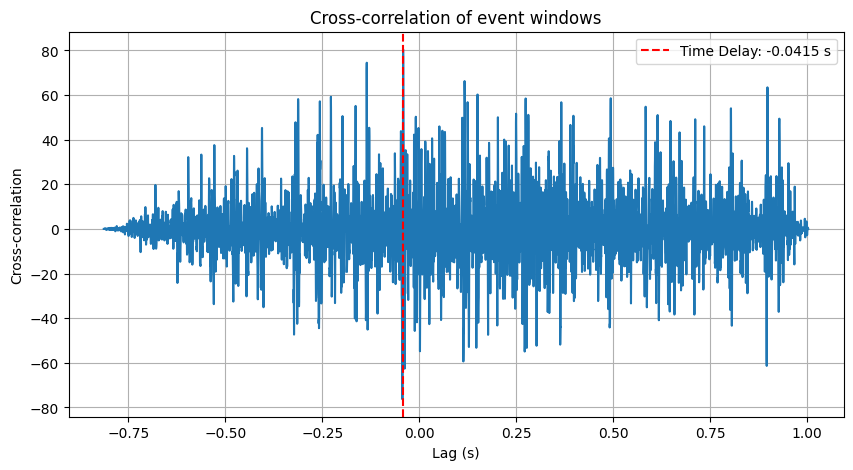

[263_1] Estimated Time Delay: -0.041549 seconds
[263_1] Estimated Source Location: 101.26 m


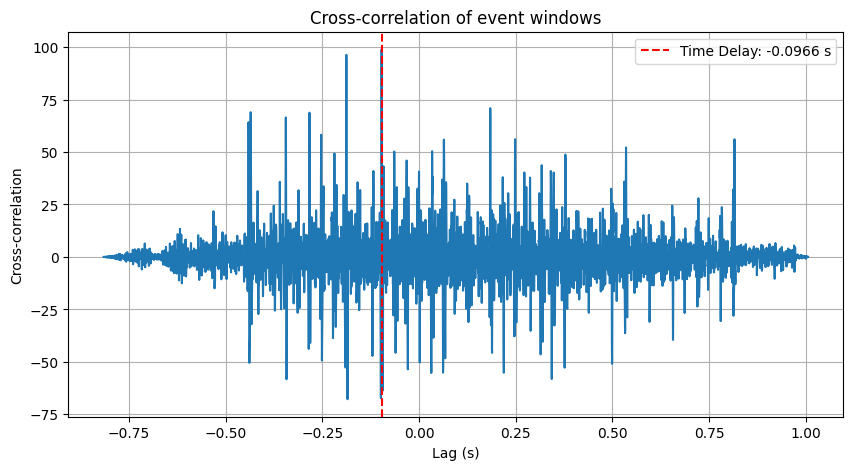

[263_2] Estimated Time Delay: -0.096631 seconds
[263_2] Estimated Source Location: 233.18 m


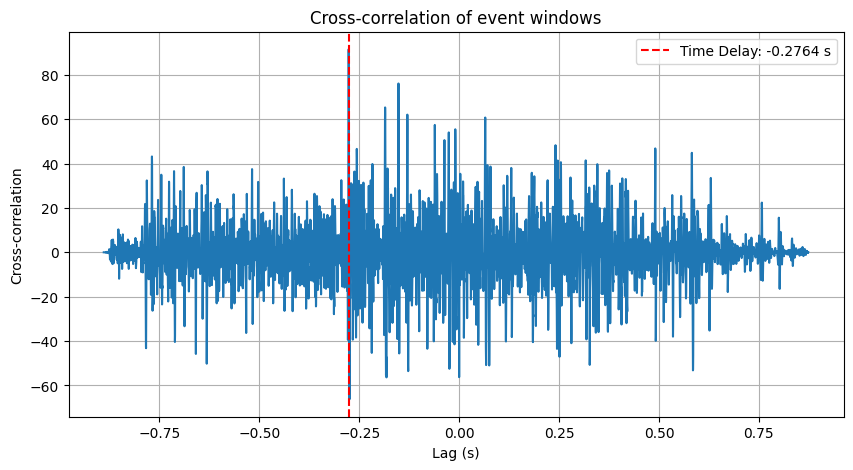

[263_3] Estimated Time Delay: -0.276439 seconds
[263_3] Estimated Source Location: 663.82 m


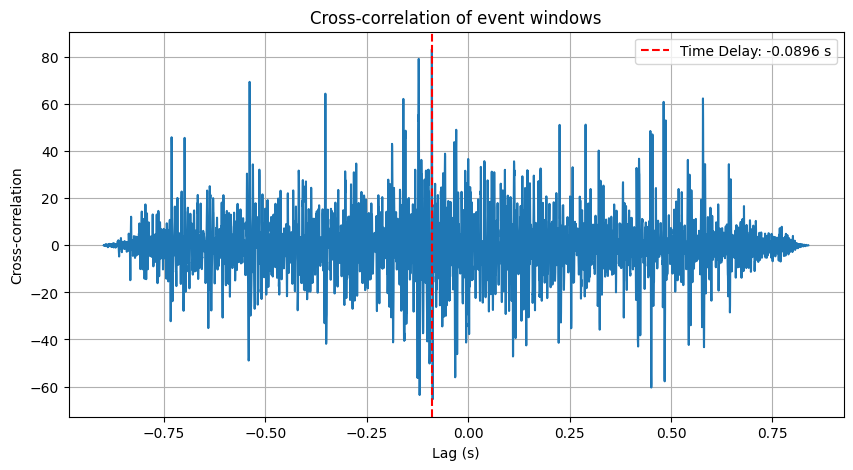

[263_4] Estimated Time Delay: -0.089557 seconds
[263_4] Estimated Source Location: 216.24 m


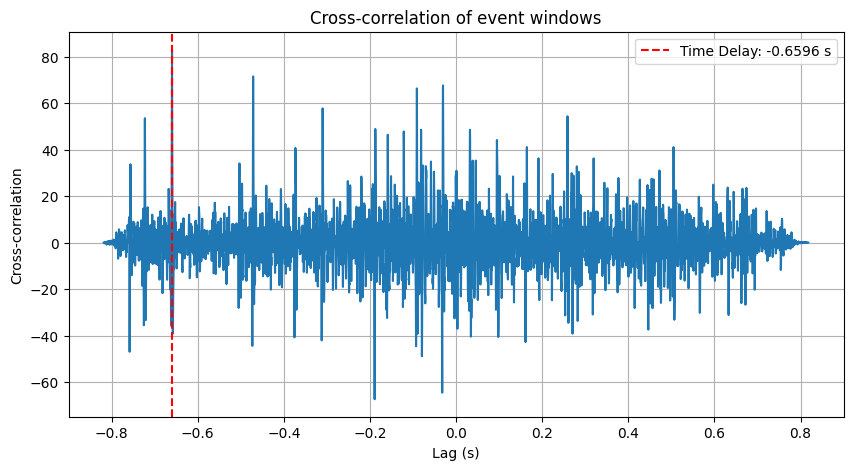

[263_5] Estimated Time Delay: -0.659558 seconds
[263_5] Estimated Source Location: 1581.39 m


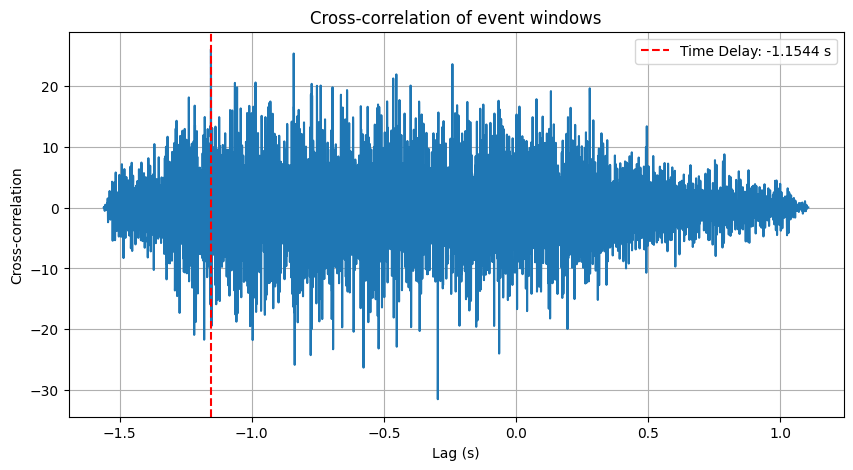

[155_1] Estimated Time Delay: -1.154398 seconds
[155_1] Estimated Source Location: 2766.53 m


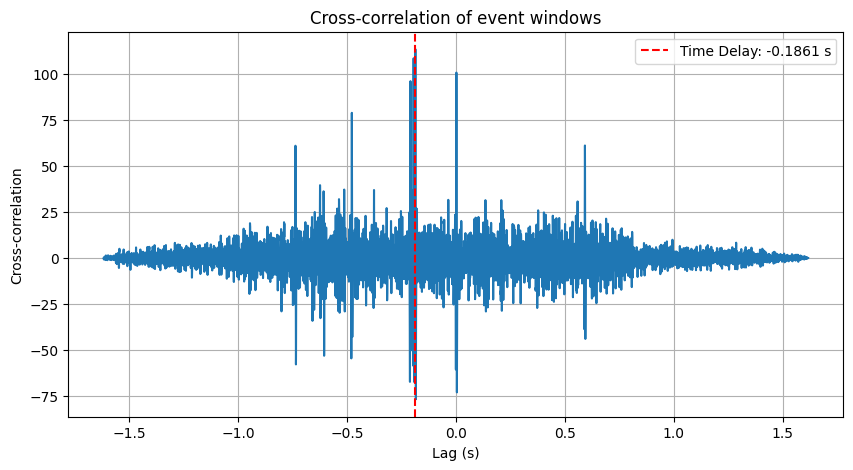

[155_2] Estimated Time Delay: -0.186084 seconds
[155_2] Estimated Source Location: 447.42 m


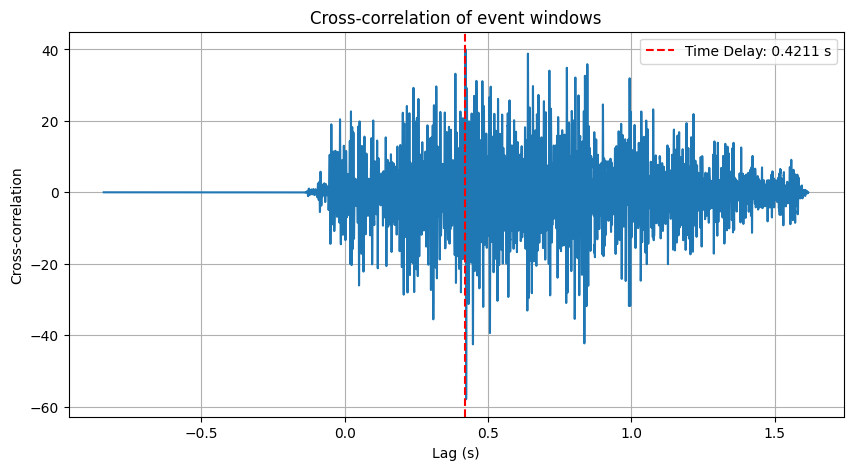

[155_3] Estimated Time Delay: 0.421087 seconds
[155_3] Estimated Source Location: -1006.75 m


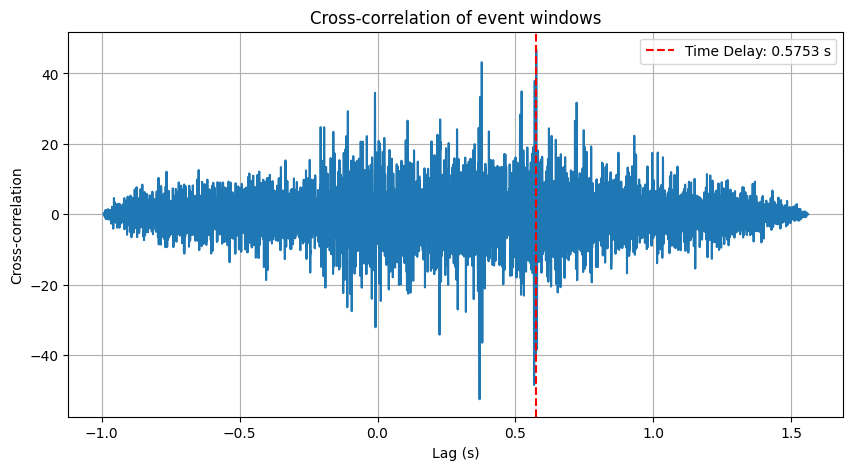

[155_4] Estimated Time Delay: 0.575265 seconds
[155_4] Estimated Source Location: -1376.01 m


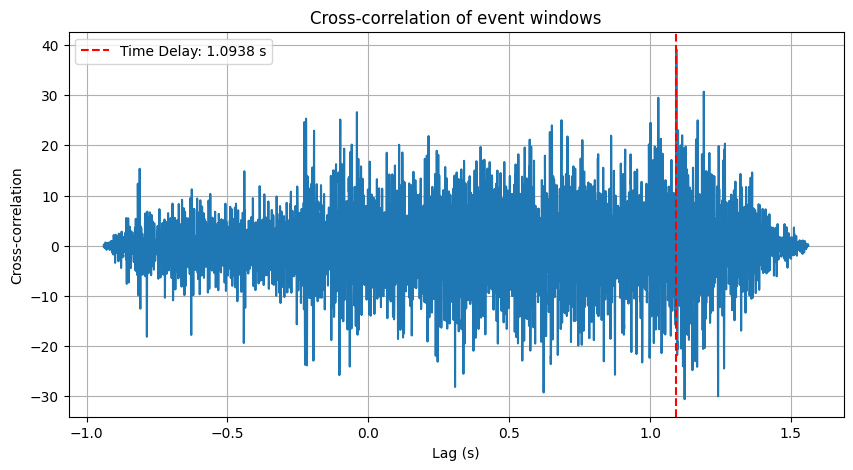

[155_5] Estimated Time Delay: 1.093750 seconds
[155_5] Estimated Source Location: -2617.78 m


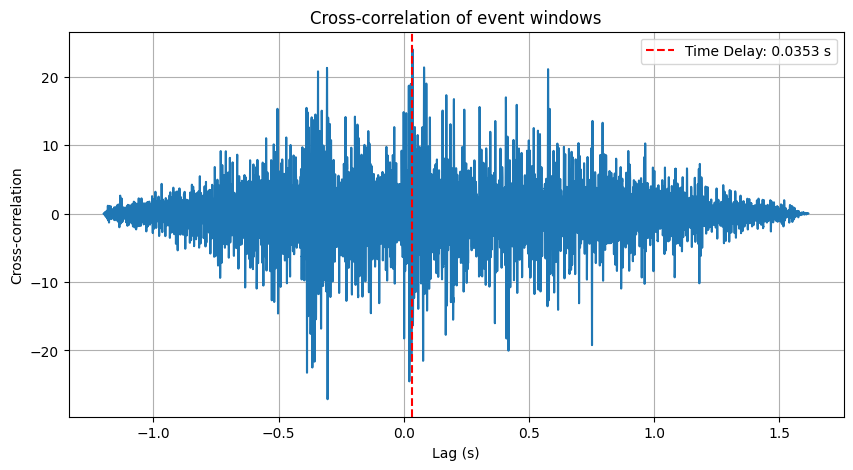

[50_1] Estimated Time Delay: 0.035252 seconds
[50_1] Estimated Source Location: -82.68 m
No event detected.


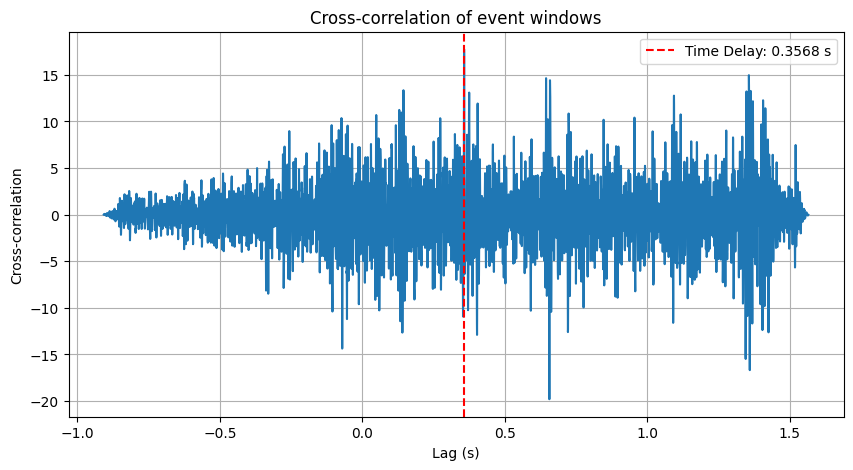

[50_3] Estimated Time Delay: 0.356796 seconds
[50_3] Estimated Source Location: -852.78 m


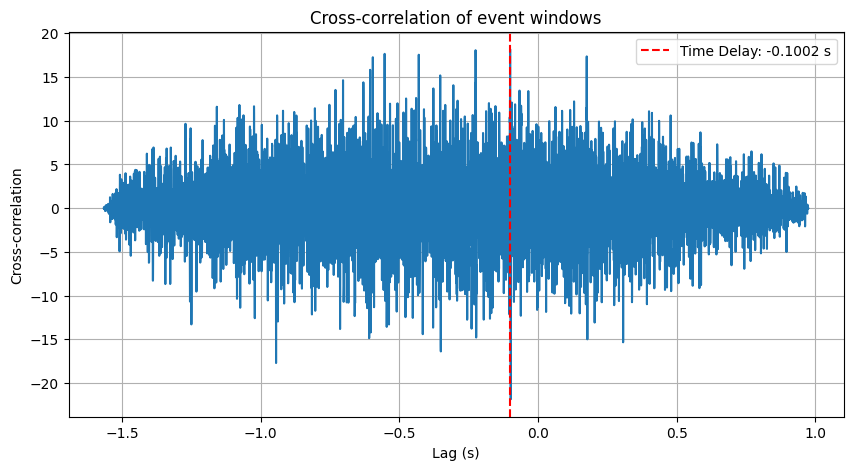

[50_4] Estimated Time Delay: -0.100235 seconds
[50_4] Estimated Source Location: 241.81 m


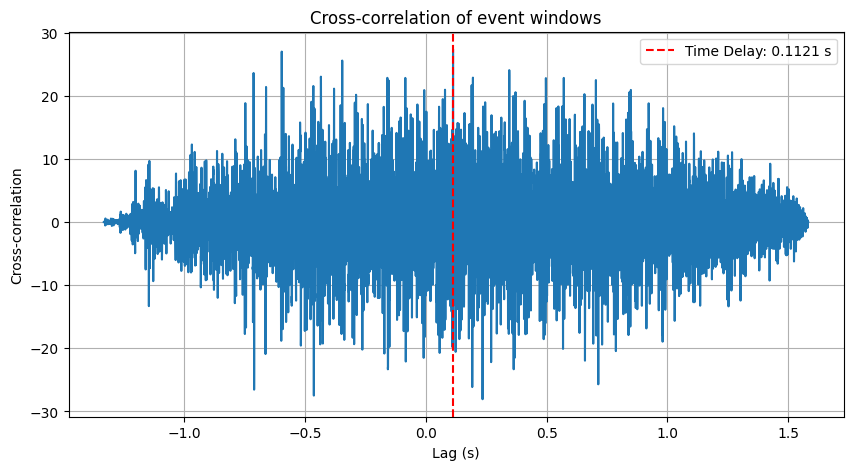

[50_5] Estimated Time Delay: 0.112101 seconds
[50_5] Estimated Source Location: -266.73 m


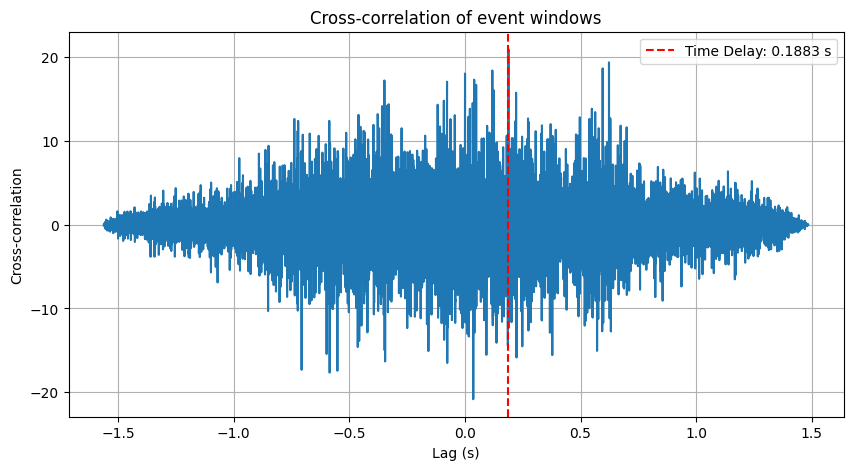

[static_1] Estimated Time Delay: 0.188334 seconds
[static_1] Estimated Source Location: -449.31 m


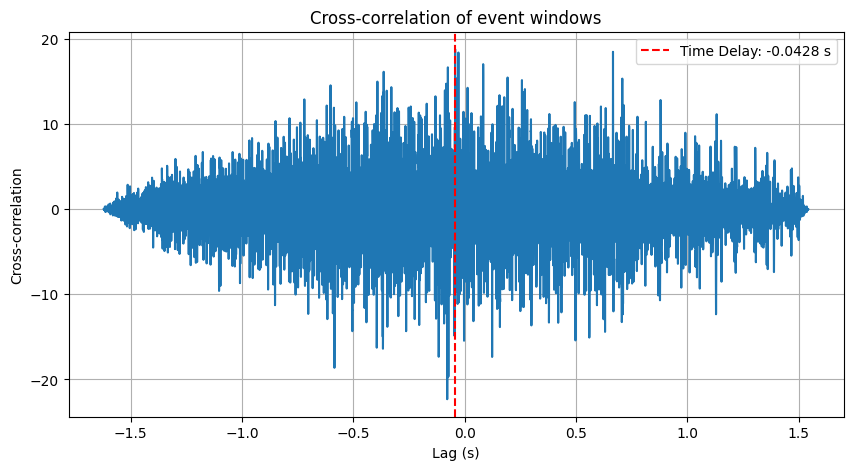

[static_2] Estimated Time Delay: -0.042781 seconds
[static_2] Estimated Source Location: 104.21 m


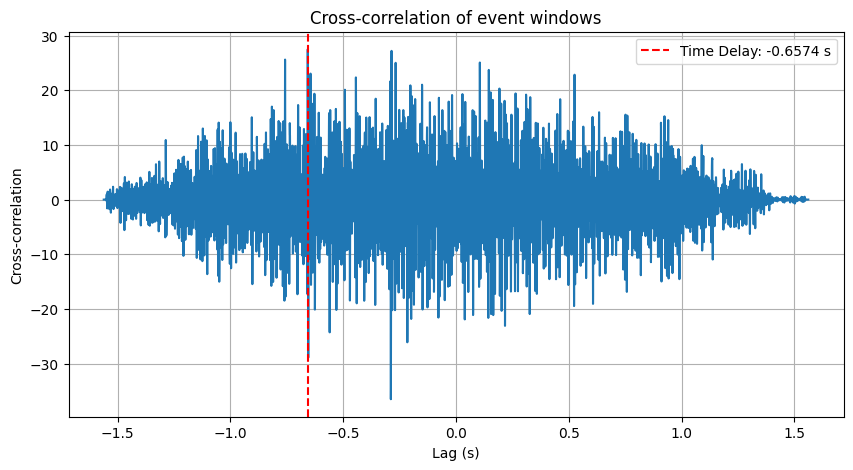

[static_3] Estimated Time Delay: -0.657356 seconds
[static_3] Estimated Source Location: 1576.12 m


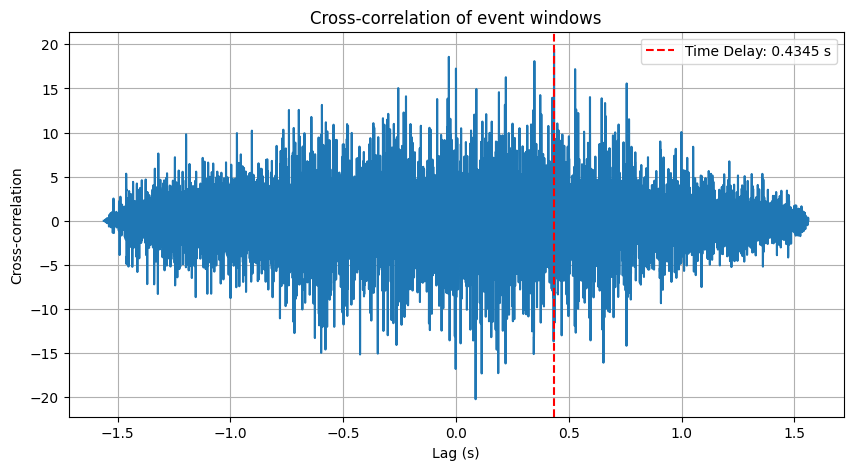

[static_4] Estimated Time Delay: 0.434525 seconds
[static_4] Estimated Source Location: -1038.94 m


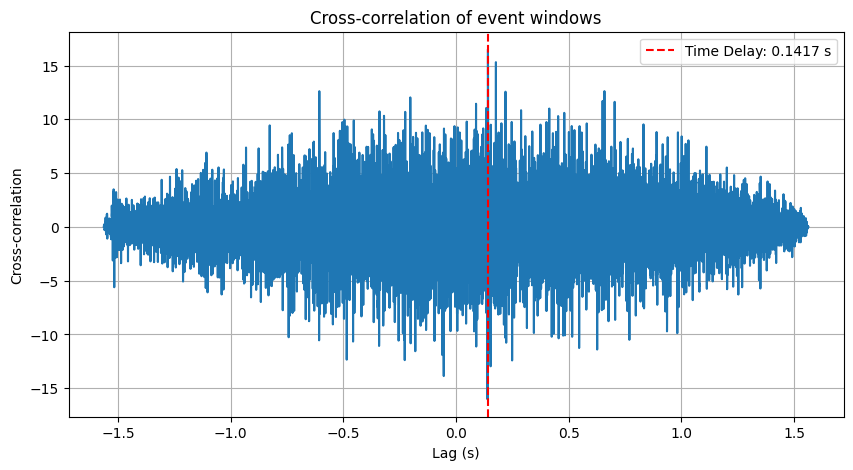

[static_5] Estimated Time Delay: 0.141700 seconds
[static_5] Estimated Source Location: -337.62 m


In [23]:
csd_results = analyze_tdoa_location(data_dict)